# Fase 4 (parte B) — CNN desde cero
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas

---
CNN entrenada **desde cero**: 3 bloques Conv→BatchNorm→MaxPool + GAP + Dense +
Dropout, con data augmentation, `class_weight` y callbacks.

**Ablation:** entrenamos la CNN con dos variantes de train —**con** y **sin** los
recortes de Mixed (`mixed_seg`)— con idénticos val/test, y guardamos la ganadora.

In [1]:
import sys, pathlib, os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from src.config import QUALITY_CLASSES, CNN_IMG_SIZE, MODELS_DIR, FIGURES_DIR, SEED
from src.data.preprocessing import load_manifest
from src.data.paths import load_image_rgb
tf.random.set_seed(SEED); np.random.seed(SEED)
print("TF", tf.__version__, "| img", CNN_IMG_SIZE)

I0000 00:00:1780819018.695607 1142077 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1780819021.405629 1142077 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TF 2.21.0 | img (96, 96)


## 1. Cargar imágenes en memoria (train completo / sin mixed_seg / val / test)

In [2]:
def load_df(m, size=CNN_IMG_SIZE):
    X=np.zeros((len(m),*size,3),np.float32); keep=np.ones(len(m),bool)
    for i,p in enumerate(m['abs_path']):
        im=load_image_rgb(p)
        if im is None: keep[i]=False; continue
        X[i]=cv2.resize(im,size).astype(np.float32)/255.0
    return X[keep], m['quality_idx'].values[keep]
m_tr=load_manifest('train'); m_trn=m_tr[m_tr['source']!='mixed_seg']
Xtr,ytr   = load_df(m_tr)
Xtrn,ytrn = load_df(m_trn)
Xva,yva   = load_df(load_manifest('val'))
Xte,yte   = load_df(load_manifest('test'))
print(f"train completo={len(Xtr)} | sin mixed_seg={len(Xtrn)} | val={len(Xva)} | test={len(Xte)}")

train completo=6591 | sin mixed_seg=5066 | val=1058 | test=1076


## 2. Arquitectura y entrenamiento (función reutilizable)

In [3]:
def build_cnn():
    aug = models.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.08),
                             layers.RandomZoom(0.10), layers.RandomBrightness(0.10, value_range=(0,1))])
    m = models.Sequential([
        layers.Input((*CNN_IMG_SIZE,3)), aug,
        layers.Conv2D(32,3,padding='same',activation='relu'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(64,3,padding='same',activation='relu'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.Conv2D(128,3,padding='same',activation='relu'), layers.BatchNormalization(), layers.MaxPooling2D(),
        layers.GlobalAveragePooling2D(), layers.Dense(128,activation='relu'), layers.Dropout(0.5),
        layers.Dense(len(QUALITY_CLASSES), activation='softmax')])
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

def train_variant(Xt, yt, tag):
    tf.keras.utils.set_random_seed(SEED)
    cw = dict(enumerate(compute_class_weight('balanced', classes=np.unique(yt), y=yt)))
    cbs=[callbacks.EarlyStopping(monitor='val_loss',patience=6,restore_best_weights=True),
         callbacks.ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=3,min_lr=1e-5)]
    m=build_cnn()
    h=m.fit(Xt,yt,validation_data=(Xva,yva),epochs=40,batch_size=32,
            class_weight=cw,callbacks=cbs,verbose=2)
    p=m.predict(Xte,verbose=0).argmax(1)
    acc=accuracy_score(yte,p); f1=f1_score(yte,p,average='macro')
    print(f"[{tag}] test accuracy={acc:.3f} | f1_macro={f1:.3f}")
    return m,h,acc,f1,p

## 3. Ablation — CNN con vs sin `mixed_seg`

In [4]:
cnn_full, h_full, acc_f, f1_f, p_f = train_variant(Xtr,  ytr,  'con mixed_seg')

E0000 00:00:1780819079.778205 1142077 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Epoch 1/40


206/206 - 86s - 416ms/step - accuracy: 0.6069 - loss: 0.8832 - val_accuracy: 0.4197 - val_loss: 1.0714 - learning_rate: 0.0010


Epoch 2/40


206/206 - 88s - 425ms/step - accuracy: 0.6834 - loss: 0.7325 - val_accuracy: 0.6059 - val_loss: 0.8978 - learning_rate: 0.0010


...

Epoch 26/40


206/206 - 73s - 355ms/step - accuracy: 0.8897 - loss: 0.2801 - val_accuracy: 0.8497 - val_loss: 0.5144 - learning_rate: 6.2500e-05


Epoch 27/40


206/206 - 74s - 361ms/step - accuracy: 0.8924 - loss: 0.2813 - val_accuracy: 0.8563 - val_loss: 0.4852 - learning_rate: 6.2500e-05


[con mixed_seg] test accuracy=0.886 | f1_macro=0.886


In [5]:
cnn_nomix, h_nomix, acc_n, f1_n, p_n = train_variant(Xtrn, ytrn, 'sin mixed_seg')

Epoch 1/40


159/159 - 61s - 387ms/step - accuracy: 0.6757 - loss: 0.7911 - val_accuracy: 0.4820 - val_loss: 1.1885 - learning_rate: 0.0010


Epoch 2/40


159/159 - 58s - 368ms/step - accuracy: 0.7566 - loss: 0.6321 - val_accuracy: 0.5227 - val_loss: 1.1222 - learning_rate: 0.0010


Epoch 3/40


...

Epoch 10/40


159/159 - 60s - 378ms/step - accuracy: 0.8602 - loss: 0.3576 - val_accuracy: 0.7136 - val_loss: 0.8468 - learning_rate: 5.0000e-04


Epoch 11/40


159/159 - 59s - 373ms/step - accuracy: 0.8711 - loss: 0.3435 - val_accuracy: 0.7826 - val_loss: 0.7724 - learning_rate: 5.0000e-04


[sin mixed_seg] test accuracy=0.753 | f1_macro=0.755


In [6]:
abl=pd.DataFrame([{'variante':'con mixed_seg','accuracy':acc_f,'f1_macro':f1_f},
                  {'variante':'sin mixed_seg','accuracy':acc_n,'f1_macro':f1_n}]).set_index('variante')
print(abl.round(4).to_string())
best_tag = 'con mixed_seg' if f1_f>=f1_n else 'sin mixed_seg'
cnn, hist, pred = (cnn_full,h_full,p_f) if best_tag=='con mixed_seg' else (cnn_nomix,h_nomix,p_n)
print(f"\nMejor variante CNN: {best_tag}")
abl.to_csv(MODELS_DIR/"ablation_cnn.csv")

               accuracy  f1_macro
variante                         
con mixed_seg    0.8857    0.8856
sin mixed_seg    0.7528    0.7551

Mejor variante CNN: con mixed_seg


## 4. Curvas de aprendizaje (variante ganadora)

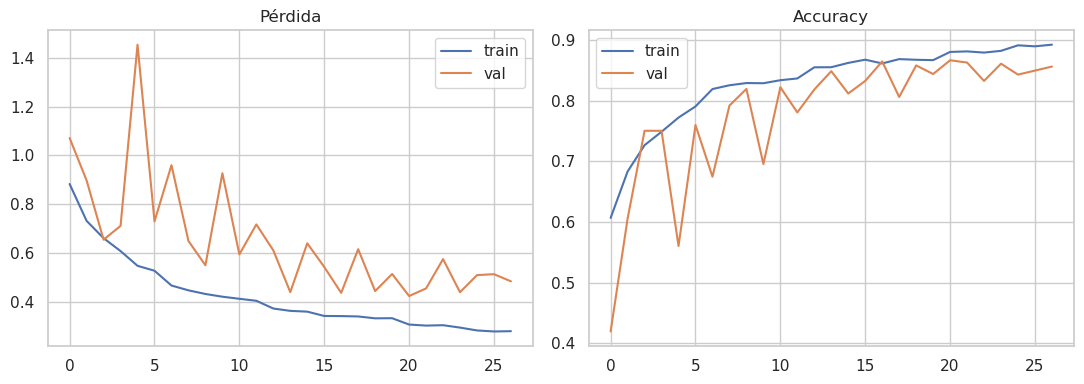

In [7]:
h=hist.history
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(h['loss'],label='train'); ax[0].plot(h['val_loss'],label='val'); ax[0].set_title('Pérdida'); ax[0].legend()
ax[1].plot(h['accuracy'],label='train'); ax[1].plot(h['val_accuracy'],label='val'); ax[1].set_title('Accuracy'); ax[1].legend()
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase4_cnn_curvas.pdf", bbox_inches="tight"); plt.show()

## 5. Evaluación en test (variante ganadora)

CNN (con mixed_seg) -> accuracy=0.886 | f1_macro=0.886

              precision    recall  f1-score   support

     Premium      0.825     0.929     0.874       365
    Estándar      0.929     0.804     0.862       358
    Descarte      0.918     0.924     0.921       353

    accuracy                          0.886      1076
   macro avg      0.891     0.886     0.886      1076
weighted avg      0.890     0.886     0.885      1076



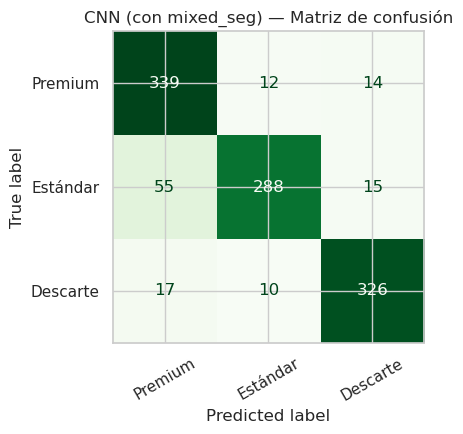

In [8]:
acc=accuracy_score(yte,pred); f1=f1_score(yte,pred,average='macro')
print(f"CNN ({best_tag}) -> accuracy={acc:.3f} | f1_macro={f1:.3f}\n")
print(classification_report(yte,pred,target_names=QUALITY_CLASSES,digits=3))
fig,axx=plt.subplots(figsize=(5,4.5))
ConfusionMatrixDisplay(confusion_matrix(yte,pred),display_labels=QUALITY_CLASSES).plot(ax=axx,cmap='Greens',colorbar=False)
axx.set_title(f'CNN ({best_tag}) — Matriz de confusión'); axx.tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase4_cnn_confusion.pdf", bbox_inches="tight"); plt.show()

## 6. Guardado

In [9]:
cnn.save(MODELS_DIR/"cnn_quality.keras")
pd.DataFrame({'modelo':['CNN'],'variante':[best_tag],'accuracy':[acc],'f1_macro':[f1]}).to_csv(MODELS_DIR/"cnn_metrics.csv", index=False)
print("Modelo guardado en models/saved/cnn_quality.keras")

Modelo guardado en models/saved/cnn_quality.keras


➡️ **Siguiente:** Fase 5 — Evaluación comparativa.